In [ ]:
'''Нужно построить модель полиномиальной регрессии для прогнозирования общего объема транзакций клиента (total_transaction_amount).

В качестве объясняющих переменных использую возраст клиента, годовой доход, количество транзакций, количество карт и количество кредитов.

Для построения моделей использую методы Ridge и Lasso. Качество моделей оцениваю на тестовой выборке с помощью MAE, RMSE и R².'''

In [ ]:
'''## 1. Загрузка и подготовка данных

В работе использю тот же датасет, который был использован в промежут атт работе.'''

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()

Saving customer_churn_features.csv to customer_churn_features.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("customer_churn_features.csv")

features = [
    "age",
    "annual_income",
    "transaction_count",
    "card_count",
    "loan_count"
]

target = "total_transaction_amount"

df_reg = df[features + [target]].copy()

print(df_reg.shape)
df_reg.head()

(10000, 6)


,age,annual_income,transaction_count,card_count,loan_count,total_transaction_amount
0,34,455276.04,266,1,0,2458127.17
1,54,1945830.96,465,1,0,2970295.94
2,18,315794.16,155,1,0,412623.55
3,18,647645.88,76,1,0,169541.05
4,49,1061109.84,165,0,0,1107569.69


In [ ]:
'''В выборке 10 000 наблюдений и 6 переменных: 5 объясняющих переменных и 1 целевая переменная.'''

In [ ]:
'''## 2. Анализ взаимосвязей между переменными

Перед построением модели посмотрим, как целевая переменная связана с каждой из объясняющих переменных.

Для этого построим точечные диаграммы. Они помогают увидеть направление и примерную форму зависимости.'''

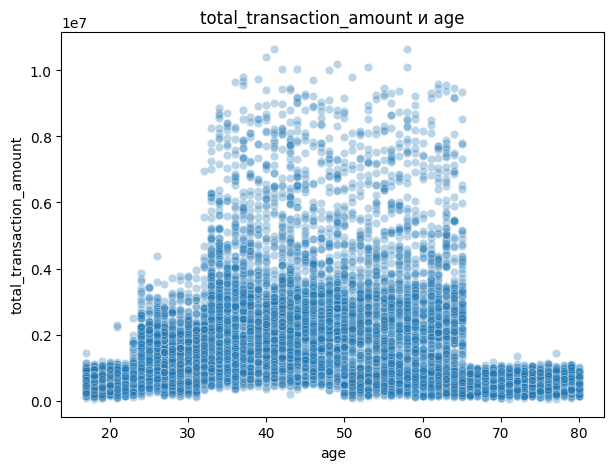

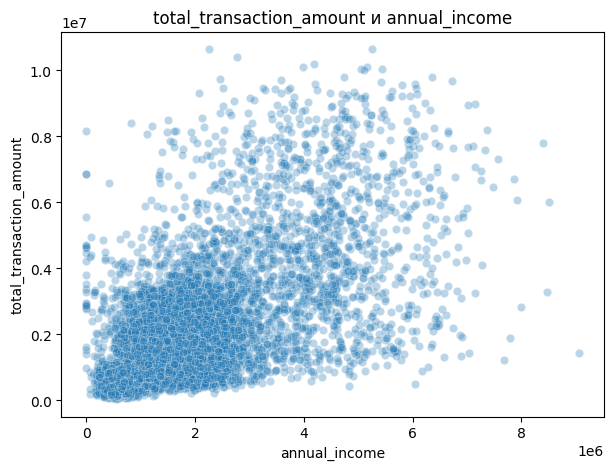

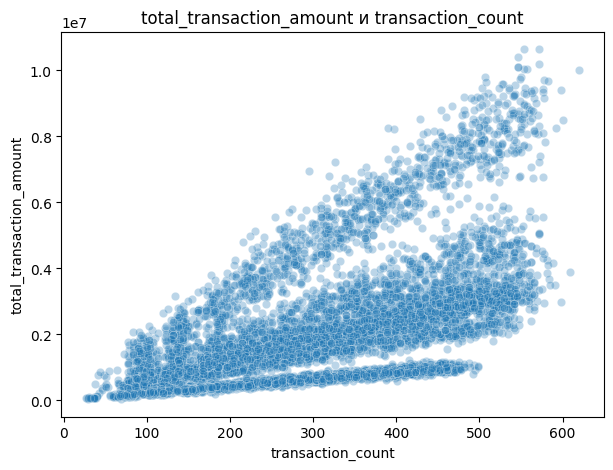

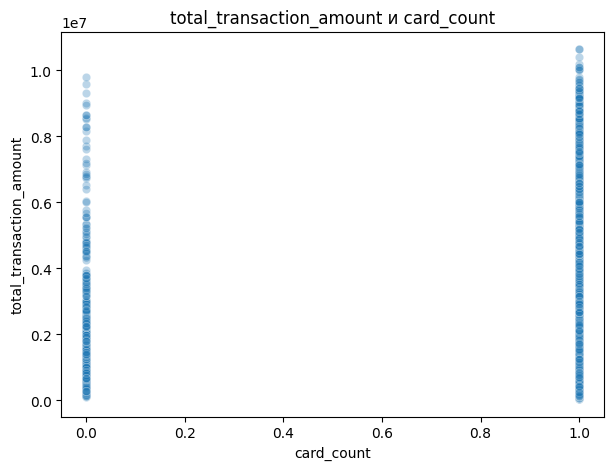

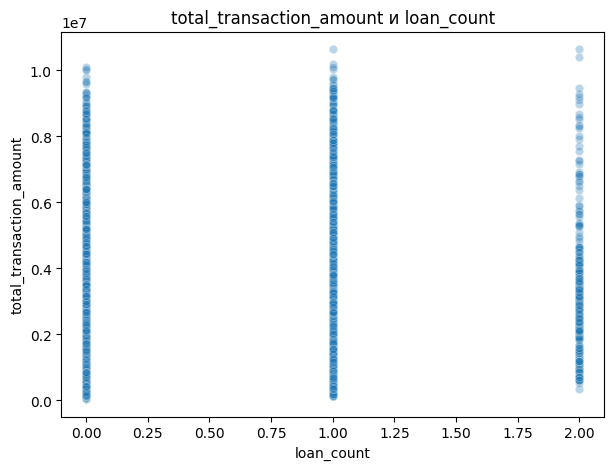

In [3]:
for feature in features:
    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=df_reg,
        x=feature,
        y=target,
        alpha=0.3
    )

    plt.title(f"{target} и {feature}")
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.show()

In [ ]:
'''### Наблюдения

По точечным диаграммам видно, что наиболее заметная положительная связь с `total_transaction_amount` наблюдается у `annual_income` и `transaction_count`.
Для `loan_count` также можно заметить положительную зависимость, но она выражена слабее.
Для `age` линейная связь выглядит слабой. Для `card_count` явной зависимости практически не видно.
При этом точечные диаграммы показывают, что зависимость не обязательно является строго линейной.
Поэтому теперь попробуем использовать полиномиальную регрессию.'''

In [ ]:
'''### Коэффициенты корреляции

Дополнительно рассчитаем коэффициент корреляции между каждой объясняющей переменной и целевой переменной.'''

In [4]:
for feature in features:
    corr = df_reg[feature].corr(df_reg[target])
    print(f"{feature}: {corr:.3f}")

age: -0.110
annual_income: 0.691
transaction_count: 0.596
card_count: -0.005
loan_count: 0.317


In [ ]:
'''Полученные значения:

- `annual_income`: 0.691
- `transaction_count`: 0.596
- `loan_count`: 0.317
- `age`: -0.110
- `card_count`: -0.005

Наиболее сильная положительная линейная связь наблюдается с `annual_income` и `transaction_count`.
Важно учитывать, что корреляция показывает только линейную взаимосвязь.
Поэтому даже при небольшой корреляции может существовать нелинейная зависимость. Для ее поиска далее используются полиномиальные признаки.'''

In [ ]:
'''## 3. Разделение данных на обучающую и тестовую выборки

Разделим данные на две части:

 80% - для обучения модели
 20% - для проверки качества модели
'''

In [5]:
from sklearn.model_selection import train_test_split

X = df_reg[features]
y = df_reg[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (8000, 5)
Тестовая выборка: (2000, 5)


In [ ]:
'''Получили 8000 наблюдений для обучения и 2000 наблюдений для тестирования'''

In [ ]:
'''## 4. Масштабирование объясняющих переменных
Перед построением моделей масштабируем объясняющие переменные.
Это особенно важно для Ridge и Lasso, поскольку эти методы используют регуляризацию и чувствительны к масштабу признаков.'''

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Размер X_train_scaled:", X_train_scaled.shape)
print("Размер X_test_scaled:", X_test_scaled.shape)

Размер X_train_scaled: (8000, 5)
Размер X_test_scaled: (2000, 5)


In [ ]:
'''Все 5 объясняющих переменных были масштабированы. Размер обучающей и тестовой выборок при этом не изменился.'''

In [ ]:
'''## 5. Создание полиномиальных признаков
Теперь расширим набор признаков с помощью полиномиального преобразования второй степени.
Кроме исходных переменных модель сможет учитывать их квадраты и взаимодействия между переменными.
Например, модель сможет учитывать не только `annual_income`, но и `annual_income²`, а также взаимодействие `annual_income × transaction_count`.'''

In [7]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print("Размер после полиномиального преобразования:")
print("X_train_poly:", X_train_poly.shape)
print("X_test_poly:", X_test_poly.shape)

Размер после полиномиального преобразования:
X_train_poly: (8000, 20)
X_test_poly: (2000, 20)


In [ ]:
'''После преобразования количество признаков увеличилось с 5 до 20.
Это произошло потому, что модель теперь использует не только исходные переменные, но и их квадраты и попарные взаимодействия.'''

In [ ]:
'''### Дополнительное масштабирование

После создания полиномиальных признаков еще раз выполним масштабирование, чтобы признаки,
полученные после возведения в квадрат и перемножения, также находились в сопоставимом масштабе.'''

In [8]:
poly_scaler = StandardScaler()

X_train_poly_scaled = poly_scaler.fit_transform(X_train_poly)
X_test_poly_scaled = poly_scaler.transform(X_test_poly)

print("Размер X_train_poly_scaled:", X_train_poly_scaled.shape)
print("Размер X_test_poly_scaled:", X_test_poly_scaled.shape)

Размер X_train_poly_scaled: (8000, 20)
Размер X_test_poly_scaled: (2000, 20)


In [ ]:
'''## 6. Модель Ridge и Lasso с пятью переменными
Сначала построим две модели на полном наборе из пяти переменных.
Используем одинаковую степень полинома — 2.
Ridge и Lasso отличаются способом регуляризации. Это позволяет сравнить их качество на одних и тех же данных.'''

In [9]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0, max_iter=10000)

ridge.fit(X_train_poly_scaled, y_train)
lasso.fit(X_train_poly_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_poly_scaled)
y_pred_lasso = lasso.predict(X_test_poly_scaled)

print("Ridge обучена")
print("Lasso обучена")

Ridge обучена
Lasso обучена


In [ ]:
'''### Оценка качества моделей

Проверим качество предсказаний на тестовой выборке.

Используем три метрики:

- MAE — средняя абсолютная ошибка
- RMSE — ошибка, которая сильнее учитывает большие отклонения
- R² — доля вариации целевой переменной, объясняемая моделью

Для MAE и RMSE меньшее значение лучше, для R² — большее.'''

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ridge
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

# Lasso
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Ridge:")
print(f"MAE:  {mae_ridge:.2f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"R²:   {r2_ridge:.4f}")

print("\nLasso:")
print(f"MAE:  {mae_lasso:.2f}")
print(f"RMSE: {rmse_lasso:.2f}")
print(f"R²:   {r2_lasso:.4f}")

Ridge:
MAE:  466939.26
RMSE: 761826.71
R²:   0.8226

Lasso:
MAE:  466946.34
RMSE: 761841.02
R²:   0.8226


In [ ]:
'''Для модели Ridge получили MAE = 466 939, RMSE = 761 827 и R² = 0.8226.
Для Lasso значения практически такие же: MAE = 466 946, RMSE = 761 841 и R² = 0.8226.
Таким образом, обе модели показывают очень близкое качество.'''

In [ ]:
'''## 7. Модель с двумя объясняющими переменными
Теперь проверим более простую спецификацию.
Оставим только `annual_income` и `transaction_count`, так как именно с ними наблюдалась наиболее заметная положительная связь с целевой переменной.
Степень полинома оставим равной 2.'''

In [11]:
features_small = ["annual_income", "transaction_count"]

X_small = df_reg[features_small]

X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_small,
    y,
    test_size=0.2,
    random_state=42
)

# Масштабирование
scaler_small = StandardScaler()

X_train_small_scaled = scaler_small.fit_transform(X_train_small)
X_test_small_scaled = scaler_small.transform(X_test_small)

# Полином 2-й степени
poly_small = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_small_poly = poly_small.fit_transform(X_train_small_scaled)
X_test_small_poly = poly_small.transform(X_test_small_scaled)

# Масштабирование полиномиальных признаков
poly_scaler_small = StandardScaler()

X_train_small_poly_scaled = poly_scaler_small.fit_transform(X_train_small_poly)
X_test_small_poly_scaled = poly_scaler_small.transform(X_test_small_poly)

print("Размер:", X_train_small_poly_scaled.shape)

Размер: (8000, 5)


In [ ]:
'''Для двух исходных переменных получили 5 полиномиальных признаков.'''

In [ ]:
'''### Обучение моделей
Теперь обучим Ridge и Lasso на сокращенном наборе переменных.'''

In [12]:
ridge_small = Ridge(alpha=1.0)
lasso_small = Lasso(alpha=1.0, max_iter=10000)

ridge_small.fit(X_train_small_poly_scaled, y_train_small)
lasso_small.fit(X_train_small_poly_scaled, y_train_small)

y_pred_ridge_small = ridge_small.predict(X_test_small_poly_scaled)
y_pred_lasso_small = lasso_small.predict(X_test_small_poly_scaled)

print("Ridge обучена")
print("Lasso обучена")

Ridge обучена
Lasso обучена


In [ ]:
'''Метрики второй спецификации'''

In [13]:
# Ridge
mae_ridge_small = mean_absolute_error(y_test_small, y_pred_ridge_small)
rmse_ridge_small = np.sqrt(mean_squared_error(y_test_small, y_pred_ridge_small))
r2_ridge_small = r2_score(y_test_small, y_pred_ridge_small)

# Lasso
mae_lasso_small = mean_absolute_error(y_test_small, y_pred_lasso_small)
rmse_lasso_small = np.sqrt(mean_squared_error(y_test_small, y_pred_lasso_small))
r2_lasso_small = r2_score(y_test_small, y_pred_lasso_small)

print("Ridge (2 переменные):")
print(f"MAE:  {mae_ridge_small:.2f}")
print(f"RMSE: {rmse_ridge_small:.2f}")
print(f"R²:   {r2_ridge_small:.4f}")

print("\nLasso (2 переменные):")
print(f"MAE:  {mae_lasso_small:.2f}")
print(f"RMSE: {rmse_lasso_small:.2f}")
print(f"R²:   {r2_lasso_small:.4f}")

Ridge (2 переменные):
MAE:  485470.77
RMSE: 803514.75
R²:   0.8027

Lasso (2 переменные):
MAE:  485488.21
RMSE: 803519.48
R²:   0.8027


In [ ]:
'''Для моделей с двумя переменными получили R² = 0.8027.

Это немного ниже, чем у моделей с пятью переменными, где R² составил около 0.8226.'''

In [ ]:
'''## 8. Сравнение всех моделей
Сведём результаты всех моделей в одну таблицу.'''

In [14]:
results = pd.DataFrame({
    "Модель": [
        "Ridge, 5 переменных, degree=2",
        "Lasso, 5 переменных, degree=2",
        "Ridge, 2 переменные, degree=2",
        "Lasso, 2 переменные, degree=2"
    ],
    "MAE": [
        mae_ridge,
        mae_lasso,
        mae_ridge_small,
        mae_lasso_small
    ],
    "RMSE": [
        rmse_ridge,
        rmse_lasso,
        rmse_ridge_small,
        rmse_lasso_small
    ],
    "R²": [
        r2_ridge,
        r2_lasso,
        r2_ridge_small,
        r2_lasso_small
    ]
})

results

,Модель,MAE,RMSE,R²
0,"Ridge, 5 переменных, degree=2",466939.260838,761826.707422,0.822618
1,"Lasso, 5 переменных, degree=2",466946.336284,761841.020359,0.822611
2,"Ridge, 2 переменные, degree=2",485470.766354,803514.752872,0.802674
3,"Lasso, 2 переменные, degree=2",485488.211891,803519.475982,0.802671


In [ ]:
'''## 9. Анализ коэффициентов Lasso

Lasso может занулять некоторые коэффициенты и тем самым автоматически отбирать признаки.

Посмотрим на коэффициенты построенной модели.'''

In [15]:
feature_names = poly.get_feature_names_out(features)

lasso_coef = pd.DataFrame({
    "Признак": feature_names,
    "Коэффициент": lasso.coef_
})

lasso_coef["Абсолютный коэффициент"] = lasso_coef["Коэффициент"].abs()

lasso_coef.sort_values(
    "Абсолютный коэффициент",
    ascending=False
)

,Признак,Коэффициент,Абсолютный коэффициент
1,annual_income,987344.813703,987344.813703
2,transaction_count,813092.462193,813092.462193
11,annual_income transaction_count,454153.424121,454153.424121
5,age^2,-192837.590529,192837.590529
4,loan_count,129600.165882,129600.165882
10,annual_income^2,-93723.042702,93723.042702
16,transaction_count loan_count,74093.340542,74093.340542
0,age,49206.468169,49206.468169
14,transaction_count^2,43054.885683,43054.885683
9,age loan_count,36008.524529,36008.524529


In [ ]:
'''При `alpha = 1.0` Lasso не занулила полностью ни один из 20 коэффициентов.
Наибольшие по абсолютной величине коэффициенты получены для `annual_income`, `transaction_count` и их взаимодействия.
Это показывает, что эти признаки имеют наиболее заметный вклад в предсказания модели в рамках выбранной спецификации.'''

In [ ]:
'''## 10. Вывод итоговый

В работе была построена модель полиномиальной регрессии для прогнозирования `total_transaction_amount`.
Были рассмотрены две спецификации: модель с пятью объясняющими переменными и более простая модель только с
`annual_income` и `transaction_count`. Для каждой спецификации были обучены модели Ridge и Lasso с полиномиальными признаками второй степени.

Лучший результат показала модель Ridge с пятью переменными. Для нее MAE составила около 466 939, RMSE — около 761 827, а R² — 0.8226.
Модель Lasso с теми же переменными показала практически такой же результат. Модели с двумя переменными были немного хуже: их R² составил около 0.8027.

Таким образом, использование пяти объясняющих переменных позволило немного улучшить качество прогнозирования по сравнению с
использованием только двух наиболее связанных с таргетом переменных.
Полученная модель объясняет около 82% вариации общего объема транзакций на тестовой выборке.
При этом ошибки предсказания остаются достаточно большими, поэтому модель не описывает поведение целевой переменной полностью.

Важно отметить, что полученные результаты показывают статистические взаимосвязи между переменными и не означают наличие причинно-следственной связи.
'''